# Feature engineering notebook

In [42]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

In [3]:
# Loading data
df = pd.read_csv(r"C:\Users\diego\Documents\ml_projects\iris\IRIS_cleaned.csv")

## Feature extraction
- Ratio of features
- Product of features
- Difference of features

In [4]:
# Add ratio column
df['sepal_ratio'] = df['sepal_length'] / df['sepal_width']

In [5]:
# Add petal ratio column
df['petal_ratio'] = df['petal_length'] / df['petal_width']

In [6]:
# Add sepal product column
df['sepal_product'] = df['sepal_length'] * df['sepal_width']

In [7]:
# Add petal product column
df['petal_product'] = df['petal_length'] * df['petal_width']

In [8]:
# Add sepal difference column
df['sepal_difference'] = df['sepal_length'] - df['sepal_width']

In [9]:
# Add petal difference column
df['petal_difference'] = df['petal_length'] - df['petal_width']

In [10]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_ratio,petal_ratio,sepal_product,petal_product,sepal_difference,petal_difference
0,5.1,3.5,1.4,0.2,Iris-setosa,1.457143,7.0,17.85,0.28,1.6,1.2
1,4.9,3.0,1.4,0.2,Iris-setosa,1.633333,7.0,14.70,0.28,1.9,1.2
2,4.7,3.2,1.3,0.2,Iris-setosa,1.468750,6.5,15.04,0.26,1.5,1.1
3,4.6,3.1,1.5,0.2,Iris-setosa,1.483871,7.5,14.26,0.30,1.5,1.3
4,5.0,3.6,1.4,0.2,Iris-setosa,1.388889,7.0,18.00,0.28,1.4,1.2


In [11]:
# Drop label column
df_features = df.drop(columns=['species'])

## Feature Selection

In [12]:
# Variance of features
print("Variance of features:\n", df_features.var())

Variance of features:
 sepal_length         0.687407
sepal_width          0.190977
petal_length         3.094471
petal_width          0.574373
sepal_ratio          0.160035
petal_ratio          5.588961
sepal_product       11.453389
petal_product       22.130801
sepal_difference     0.957602
petal_difference     1.104110
dtype: float64


### Correlation analysis

In [13]:
# Covariance matrix of features
print("\nCovariance matrix of features:\n", df_features.corr())


Covariance matrix of features:
                   sepal_length  sepal_width  petal_length  petal_width  \
sepal_length          1.000000    -0.109321      0.871305     0.817058   
sepal_width          -0.109321     1.000000     -0.421057    -0.356376   
petal_length          0.871305    -0.421057      1.000000     0.961883   
petal_width           0.817058    -0.356376      0.961883     1.000000   
sepal_ratio           0.725953    -0.746349      0.834384     0.748146   
petal_ratio          -0.573256     0.354257     -0.701865    -0.751847   
sepal_product         0.680811     0.648061      0.363047     0.372439   
petal_product         0.856983    -0.278412      0.957473     0.980094   
sepal_difference      0.896076    -0.539201      0.926252     0.851407   
petal_difference      0.869360    -0.447862      0.980356     0.889051   

                  sepal_ratio  petal_ratio  sepal_product  petal_product  \
sepal_length         0.725953    -0.573256       0.680811       0.856983   


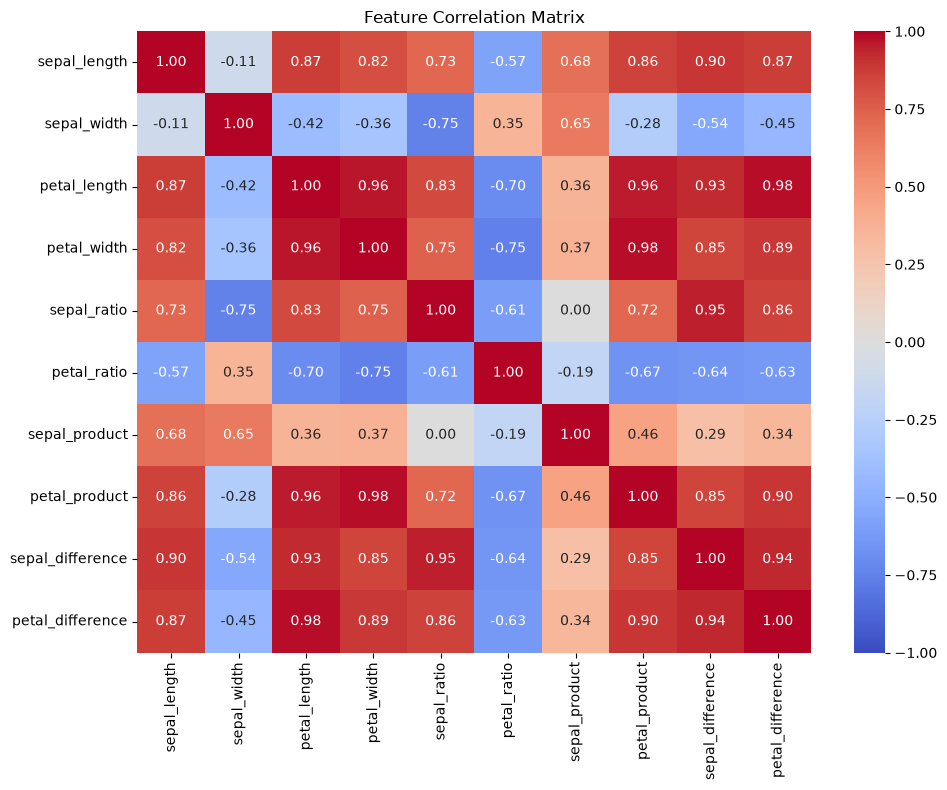

In [14]:
# Plotting correlation heatmap

corr = df_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [15]:
# Make a list of correlation pairs with the upper triangle of the correlation matrix
corr_pairs = (corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool)).stack().reset_index().dropna())

In [16]:
# Create a DataFrame with correlation pairs and their values
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Add a column for absolute correlation values
corr_pairs['abs_correlation'] = corr_pairs['Correlation'].abs()

# Sort the DataFrame by absolute correlation values in descending order
corr_pairs = corr_pairs.sort_values(by='abs_correlation', ascending=False)

In [17]:
print(corr_pairs)

           Feature_1         Feature_2  Correlation  abs_correlation
29      petal_length  petal_difference     0.980356         0.980356
37       petal_width     petal_product     0.980094         0.980094
23      petal_length       petal_width     0.961883         0.961883
27      petal_length     petal_product     0.957473         0.957473
48       sepal_ratio  sepal_difference     0.948370         0.948370
89  sepal_difference  petal_difference     0.936575         0.936575
28      petal_length  sepal_difference     0.926252         0.926252
8       sepal_length  sepal_difference     0.896076         0.896076
79     petal_product  petal_difference     0.896025         0.896025
39       petal_width  petal_difference     0.889051         0.889051
2       sepal_length      petal_length     0.871305         0.871305
9       sepal_length  petal_difference     0.869360         0.869360
49       sepal_ratio  petal_difference     0.857254         0.857254
7       sepal_length     petal_pro

In [18]:
corr_pairs.describe()

,Correlation,abs_correlation
count,45.000000,45.000000
mean,0.315962,0.656532
std,0.637563,0.260301
min,-0.751847,0.000632
25%,-0.356376,0.447862
50%,0.648061,0.722458
75%,0.869360,0.869360
max,0.980356,0.980356


In [19]:
threshold = 0.7

strong = corr_pairs[corr_pairs['abs_correlation']>=threshold]

print("Number of strong correlations:", len(strong))

feature_counts = pd.concat([strong['Feature_1'], strong['Feature_2']]).value_counts()

print("Feature counts in strong correlations:\n", feature_counts)

Number of strong correlations: 24
Feature counts in strong correlations:
 petal_length        7
petal_width         7
sepal_ratio         7
sepal_difference    6
sepal_length        6
petal_product       6
petal_difference    6
petal_ratio         2
sepal_width         1
Name: count, dtype: int64


In [20]:
mean_corr = {}

for feature in corr.columns:
    values = corr.loc[feature].drop(feature).abs() # Exclude self-correlation
    mean_corr[feature] = values.mean()

mean_corr = pd.Series(mean_corr).sort_values(ascending=False)

print("Mean correlation of features:\n", mean_corr)

Mean correlation of features:
 petal_length        0.779736
sepal_difference    0.764401
petal_difference    0.760930
petal_width         0.747589
petal_product       0.740900
sepal_length        0.711125
sepal_ratio         0.687676
petal_ratio         0.568723
sepal_width         0.433433
sepal_product       0.370806
dtype: float64


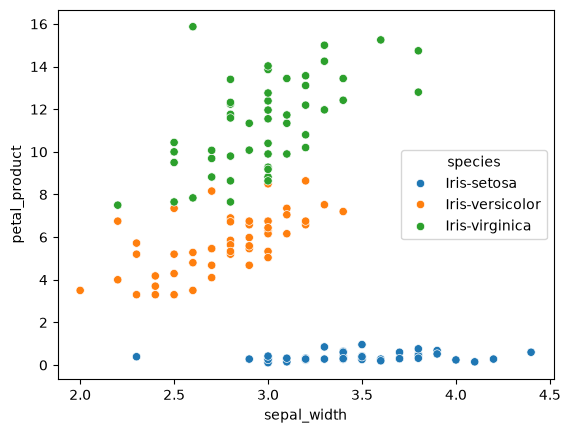

In [21]:
# Create a scatter plot, to visualize the pair of features correlation
sns.scatterplot(data=df_features, x='sepal_width', y='petal_product', hue=df['species'])

plt.show()

## Mutual information analysis

In [ ]:
# Mutual information between features and target variable


mi_scores = mutual_info_classif(df_features, df['species'])
print("\nMutual Information scores:\n", mi_scores)


Mutual Information scores:
 [0.46211439 0.26585462 0.98727885 0.98491406 0.62159341 0.6190269
 0.00567976 1.0433374  0.70270056 0.74229279]


In [23]:
# Create mutual information dataframe
mi_df = pd.DataFrame({'Features': df_features.columns, 'Mutual_information': mi_scores})

# Sorting the df
mi_df = mi_df.sort_values(by='Mutual_information', ascending=False)

print("Mutual Information scores:\n", mi_df)

Mutual Information scores:
            Features  Mutual_information
7     petal_product            1.043337
2      petal_length            0.987279
3       petal_width            0.984914
9  petal_difference            0.742293
8  sepal_difference            0.702701
4       sepal_ratio            0.621593
5       petal_ratio            0.619027
0      sepal_length            0.462114
1       sepal_width            0.265855
6     sepal_product            0.005680


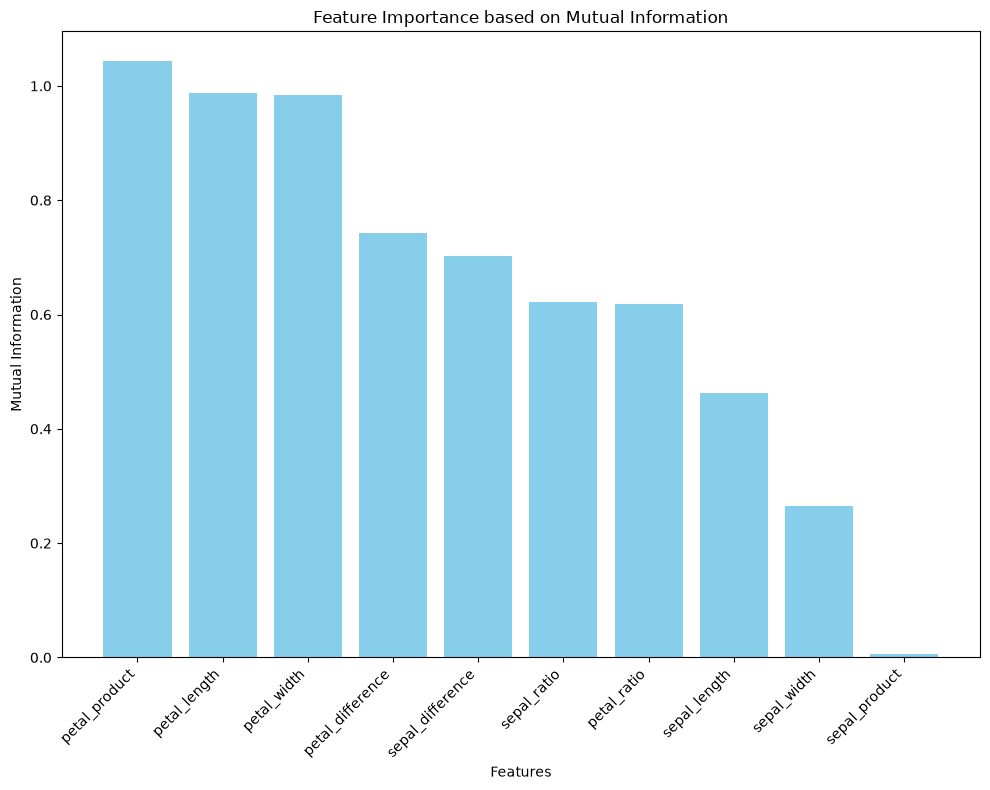

In [24]:
# Plotting mutual information scores
plt.figure(figsize=(10,8))

plt.bar(mi_df['Features'], mi_df['Mutual_information'], color='skyblue')

plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.title("Feature Importance based on Mutual Information")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
comparison = mi_df.copy()

comparison["mean_abs_correlation"] = [
    corr.loc[f].drop(f).abs().mean()
    for f in comparison["Features"]
]

comparison = comparison.sort_values(by='Mutual_information', ascending=False).reset_index(drop=True)
print(comparison)



           Features  Mutual_information  mean_abs_correlation
0     petal_product            1.043337              0.740900
1      petal_length            0.987279              0.779736
2       petal_width            0.984914              0.747589
3  petal_difference            0.742293              0.760930
4  sepal_difference            0.702701              0.764401
5       sepal_ratio            0.621593              0.687676
6       petal_ratio            0.619027              0.568723
7      sepal_length            0.462114              0.711125
8       sepal_width            0.265855              0.433433
9     sepal_product            0.005680              0.370806


In [33]:
# Adding

comparison["MI_rank"] = comparison["Mutual_information"].rank(
    ascending=False,
    method="min"
)



In [34]:
comparison["correlation_rank"] = comparison["mean_abs_correlation"].rank(
    ascending=True,
    method="min"
)

In [35]:
print("Mutual Information scores with rank:\n", comparison)

Mutual Information scores with rank:
            Features  Mutual_information  mean_abs_correlation  MI_rank  \
0     petal_product            1.043337              0.740900      1.0   
1      petal_length            0.987279              0.779736      2.0   
2       petal_width            0.984914              0.747589      3.0   
3  petal_difference            0.742293              0.760930      4.0   
4  sepal_difference            0.702701              0.764401      5.0   
5       sepal_ratio            0.621593              0.687676      6.0   
6       petal_ratio            0.619027              0.568723      7.0   
7      sepal_length            0.462114              0.711125      8.0   
8       sepal_width            0.265855              0.433433      9.0   
9     sepal_product            0.005680              0.370806     10.0   

   correlation_rank  
0               6.0  
1              10.0  
2               7.0  
3               8.0  
4               9.0  
5              

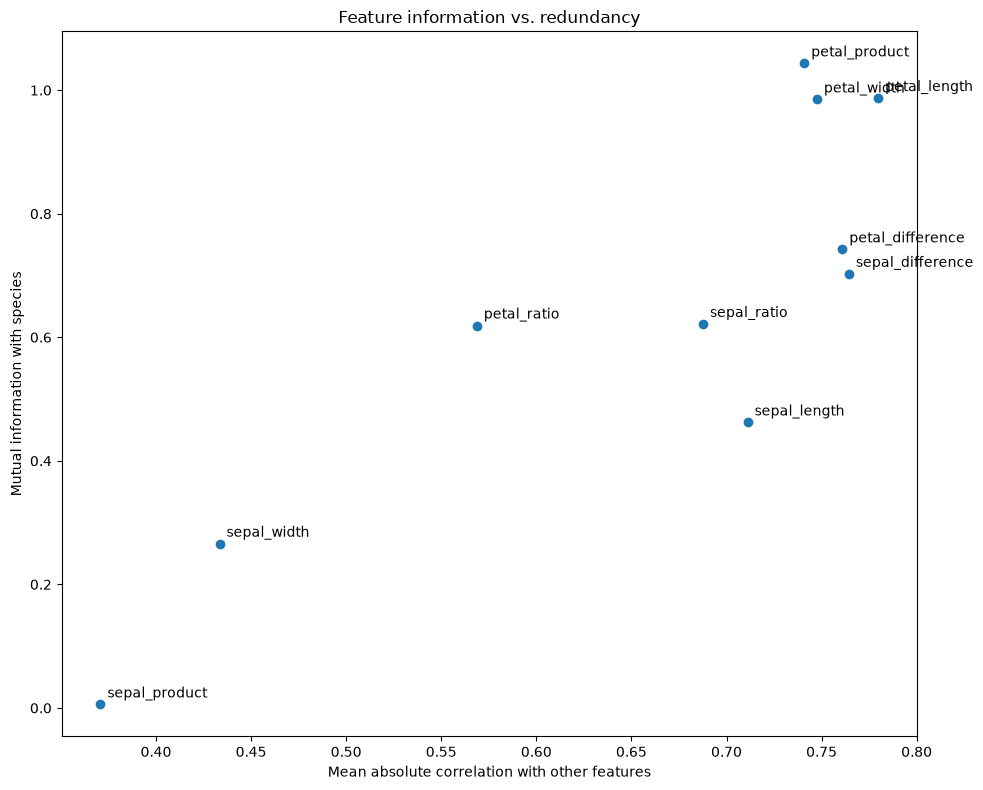

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    comparison["mean_abs_correlation"],
    comparison["Mutual_information"]
)

for _, row in comparison.iterrows():
    plt.annotate(
        row["Features"],
        (row["mean_abs_correlation"], row["Mutual_information"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Mean absolute correlation with other features")
plt.ylabel("Mutual information with species")
plt.title("Feature Mutual information vs. Average correlation")

plt.tight_layout()
plt.show()

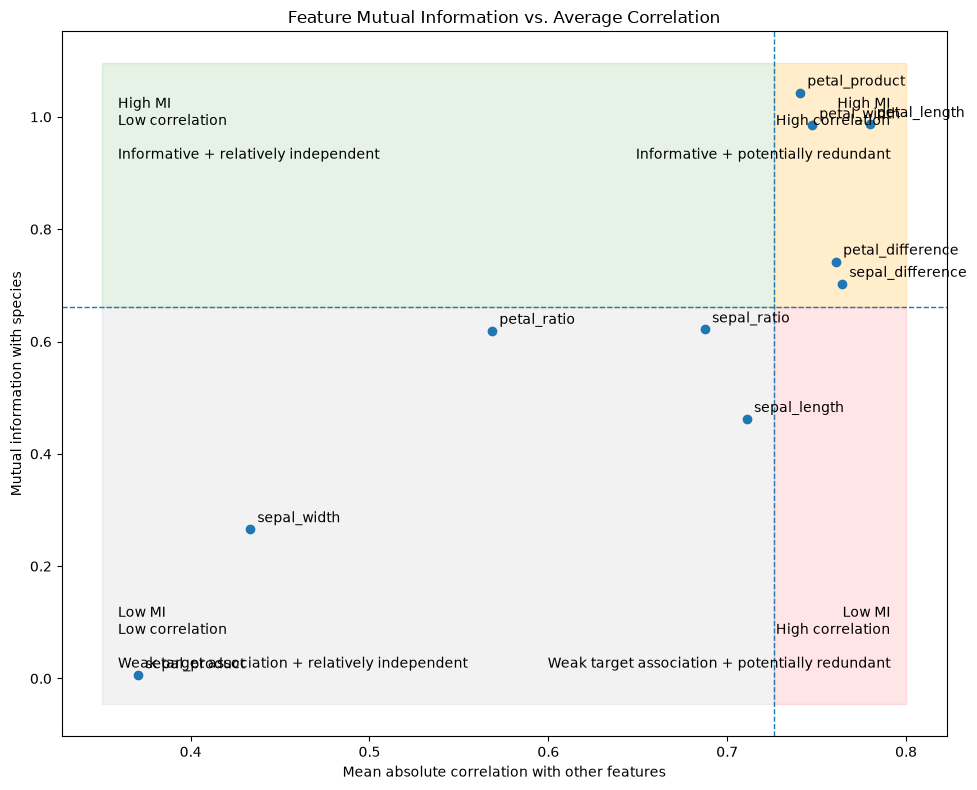

In [40]:
import matplotlib.pyplot as plt

# Median thresholds
corr_threshold = comparison["mean_abs_correlation"].median()
mi_threshold = comparison["Mutual_information"].median()

plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(
    comparison["mean_abs_correlation"],
    comparison["Mutual_information"],
    zorder=3
)

# Quadrant backgrounds
plt.axvline(
    corr_threshold,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    mi_threshold,
    linestyle="--",
    linewidth=1
)

# Get plot limits
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

# Quadrant shading
# 2nd Quadrant: High MI, Low correlation
plt.fill_between(
    [x_min, corr_threshold],
    mi_threshold, y_max,
    color="green",
    alpha=0.10
)

# 1st Quadrant: High MI, High correlation
plt.fill_between(
    [corr_threshold, x_max],
    mi_threshold, y_max,
    color="orange",
    alpha=0.20
)
# 3rd Quadrant: Low MI, Low correlation
plt.fill_between(
    [x_min, corr_threshold],
    y_min, mi_threshold,
    color="gray",
    alpha=0.10
)
# 4th Quadrant: Low MI, High correlation
plt.fill_between(
    [corr_threshold, x_max],
    y_min, mi_threshold,
    color="red",
    alpha=0.10
)

# Feature labels
for _, row in comparison.iterrows():
    plt.annotate(
        row["Features"],
        (
            row["mean_abs_correlation"],
            row["Mutual_information"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Quadrant labels
plt.text(
    x_min + 0.02 * (x_max - x_min),
    y_max - 0.05 * (y_max - y_min),
    "High MI\nLow correlation\n\nInformative + relatively independent",
    ha="left",
    va="top",
    fontsize=10
)

plt.text(
    x_max - 0.02 * (x_max - x_min),
    y_max - 0.05 * (y_max - y_min),
    "High MI\nHigh correlation\n\nInformative + potentially redundant",
    ha="right",
    va="top",
    fontsize=10
)

plt.text(
    x_min + 0.02 * (x_max - x_min),
    y_min + 0.05 * (y_max - y_min),
    "Low MI\nLow correlation\n\nWeak target association + relatively independent",
    ha="left",
    va="bottom",
    fontsize=10
)

plt.text(
    x_max - 0.02 * (x_max - x_min),
    y_min + 0.05 * (y_max - y_min),
    "Low MI\nHigh correlation\n\nWeak target association + potentially redundant",
    ha="right",
    va="bottom",
    fontsize=10
)

plt.xlabel("Mean absolute correlation with other features")
plt.ylabel("Mutual information with species")
plt.title("Feature Mutual Information vs. Average Correlation")

plt.tight_layout()
plt.show()

## Principal component analysis

In [52]:
# Make principal component analysis with the original features only

X = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]
# Normalizing data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)


print("\nCumulative explained variance:")
print(pca.explained_variance_ratio_.cumsum())

Explained variance ratio:
[0.72738591 0.23030014 0.03702645 0.0052875 ]

Cumulative explained variance:
[0.72738591 0.95768605 0.9947125  1.        ]


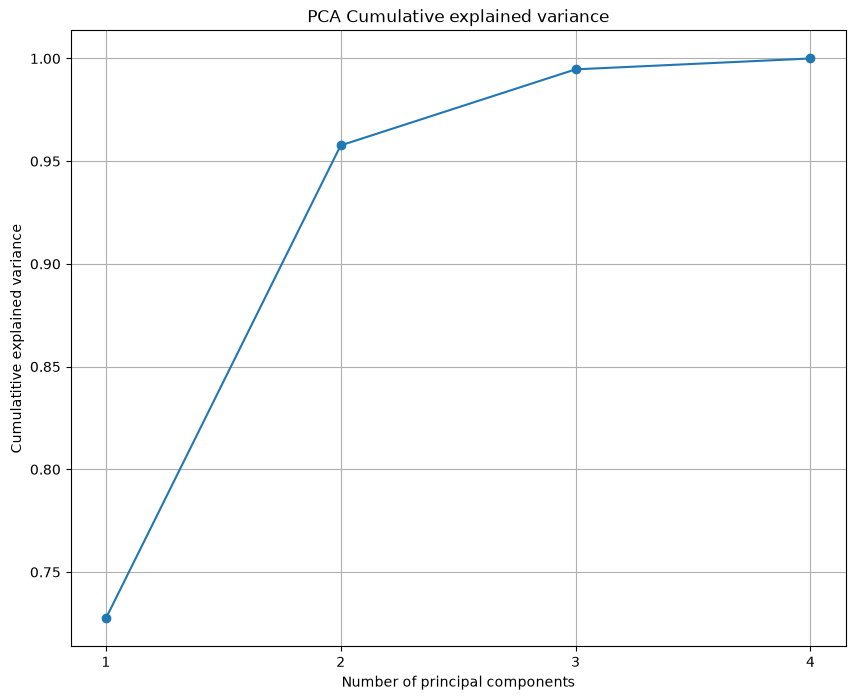

In [51]:
plt.figure(figsize=(10,8))

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulatitive explained variance")
plt.title("PCA Cumulative explained variance")
plt.xticks(range(1,5))
plt.grid(True)
plt.show()

In [55]:
# Make principal component analysis with all features

X_full = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "sepal_ratio",
    "petal_ratio",
    "petal_product",
    "sepal_product",
    "petal_difference",
    "sepal_difference"
]]
# Normalizing data
scaler2 = StandardScaler()
X_full_scaled = scaler2.fit_transform(X_full)

# PCA
pca2 = PCA()
X_pca2 = pca2.fit_transform(X_full_scaled)

print("Explained variance ratio:")
print(pca2.explained_variance_ratio_)


print("\nCumulative explained variance:")
print(pca2.explained_variance_ratio_.cumsum())

Explained variance ratio:
[7.11057260e-01 1.95218508e-01 5.44966433e-02 2.83129022e-02
 8.32958829e-03 1.26939336e-03 1.00359377e-03 3.12110332e-04
 5.32005486e-17 0.00000000e+00]

Cumulative explained variance:
[0.71105726 0.90627577 0.96077241 0.98908531 0.9974149  0.9986843
 0.99968789 1.         1.         1.        ]


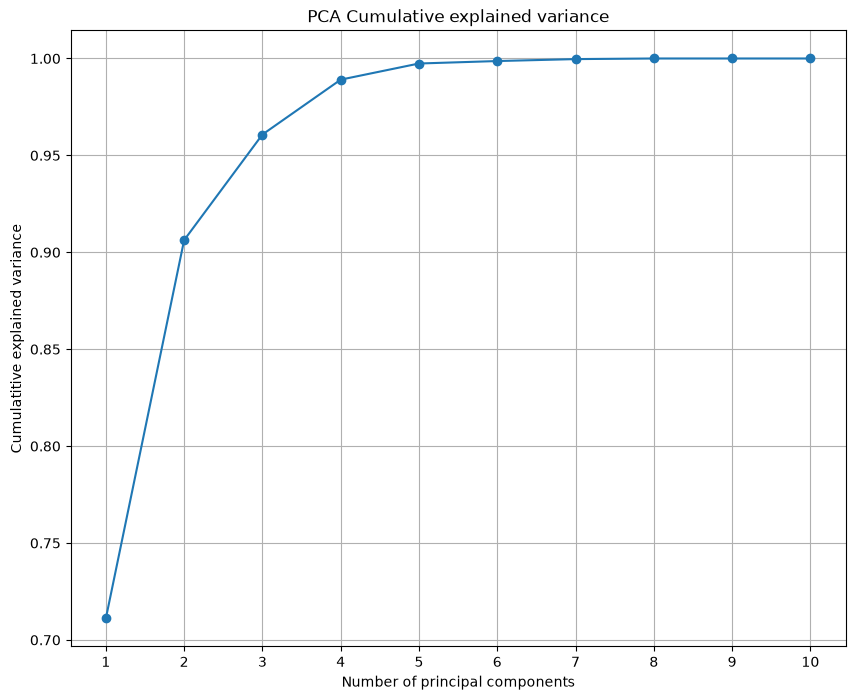

In [60]:
plt.figure(figsize=(10,8))

plt.plot(
    range(1, len(pca2.explained_variance_ratio_)+1),
    pca2.explained_variance_ratio_.cumsum(),
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulatitive explained variance")
plt.title("PCA Cumulative explained variance")
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

## Conclusions

